### ***Logistic Regression***

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

def load_and_prepare():
    # Load data first
    d = pd.read_csv('deliveries.csv')
    m = pd.read_csv('matches.csv')

    # First compute first innings total
    t1 = d[d.inning == 1].groupby('match_id')['total_runs'].sum().reset_index()
    t1 = t1.rename(columns={'total_runs': 'target'})

    # Rename id to match_id in matches dataframe
    m = m.rename(columns={'id': 'match_id'})

    # Select and rename match columns
    mdf = m[['match_id', 'city', 'winner', 'dl_applied']]

    # Get second innings deliveries and merge with match data
    d2 = d[d.inning == 2]
    d2 = d2.merge(mdf, on='match_id')
    d2 = d2.merge(t1, on='match_id')
    d2 = d2[d2.dl_applied == 0]

    # Calculate stats
    d2['current_score'] = d2.groupby('match_id')['total_runs'].cumsum()
    d2['runs_left'] = d2.target - d2.current_score + 1
    d2['balls_left'] = 126 - (d2.over*6 + d2.ball)
    d2['player_dismissed'] = d2.player_dismissed.notna().astype(int)
    wk = d2.groupby('match_id')['player_dismissed'].cumsum()
    d2['wickets'] = 10 - wk
    d2['crr'] = d2.current_score*6/(120 - d2.balls_left).replace({0: np.nan})
    d2['rrr'] = d2.runs_left*6/d2.balls_left.replace({0: np.nan})

    # Calculate win flag
    d2['winner_flag'] = (d2.winner == d2.batting_team).astype(int)

    # Final columns
    keep = [
        'batting_team', 'bowling_team', 'city',
        'runs_left', 'balls_left', 'wickets',
        'target', 'crr', 'rrr', 'winner_flag'
    ]

    return d2.dropna()[keep]

def build_model(df):
    X = df.drop('winner_flag', axis=1)
    y = df.winner_flag

    # One-hot encode categorical features
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    trf = ColumnTransformer([
        ('ohe', ohe, ['batting_team', 'bowling_team', 'city'])
    ], remainder='passthrough')

    # Build and train model
    pipe = Pipeline([
        ('trf', trf),
        ('lr', LogisticRegression(solver='liblinear'))
    ])
    pipe.fit(X, y)
    return pipe

def main():
    df = load_and_prepare()
    model = build_model(df)

    # Get user input
    bt = input("Batting team: ")
    bl = input("Bowling team: ")
    city = input("City: ")
    rl = int(input("Runs left: "))
    bls = int(input("Balls left: "))
    wk = int(input("Wickets left: "))
    tgt = int(input("Target score: "))

    # Calculate rates
    crr = ((tgt - rl + 1)*6)/(120 - bls) if bls < 120 else 0
    rrr = (rl*6)/bls if bls > 0 else float('inf')

    # Create prediction dataframe
    row = pd.DataFrame([{
        'batting_team': bt,
        'bowling_team': bl,
        'city': city,
        'runs_left': rl,
        'balls_left': bls,
        'wickets': wk,
        'target': tgt,
        'crr': crr,
        'rrr': rrr
    }])

    # Predict and show results
    p = model.predict_proba(row)[0]
    print(f"\nWin probability : {p[1]*100:.1f}%")
    print(f"Lose probability: {p[0]*100:.1f}%\n")

if __name__ == "__main__":
    main()

Batting team: Mumbai Indians
Bowling team: Chennai Super Kings
City: Chennai
Runs left: 120
Balls left: 70
Wickets left: 8
Target score: 190

Win probability : 18.0%
Lose probability: 82.0%



In [ ]:
# Add as a new cell (fixed version)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = load_and_prepare()

# Split into features and target
X = df.drop('winner_flag', axis=1)
y = df['winner_flag']

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create our model directly here instead of using build_model
ohe = OneHotEncoder(drop='first', sparse_output=False)
trf = ColumnTransformer([
    ('ohe', ohe, ['batting_team', 'bowling_team', 'city'])
], remainder='passthrough')

model = Pipeline([
    ('trf', trf),
    ('lr', LogisticRegression(solver='liblinear'))
])
model.fit(X_train, y_train)

# Make predictions on test data
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (win)
y_pred = (y_pred_proba >= 0.5).astype(int)  # Apply 50% threshold

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

# Print performance metrics
print(f"Model Performance Metrics (50% threshold):")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")

Model Performance Metrics (50% threshold):
Accuracy:  0.8382
Precision: 0.8119
Recall:    0.7662
F1 Score:  0.7884
AUC-ROC:   0.9118


In [ ]:
# Display detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Lose', 'Win']))

# Calculate how many matches were correctly predicted
total_test_matches = len(y_test)
correct_predictions = sum(y_test == y_pred)
print(f"\nCorrectly predicted {correct_predictions} out of {total_test_matches} matches")
print(f"({correct_predictions/total_test_matches:.1%} accuracy)")


Detailed Classification Report:
              precision    recall  f1-score   support

        Lose       0.85      0.88      0.87       356
         Win       0.81      0.77      0.79       231

    accuracy                           0.84       587
   macro avg       0.83      0.83      0.83       587
weighted avg       0.84      0.84      0.84       587


Correctly predicted 492 out of 587 matches
(83.8% accuracy)


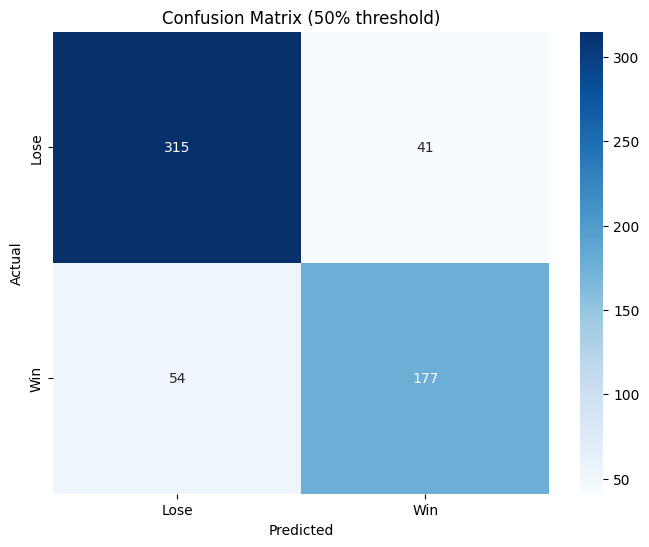

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lose', 'Win'],
            yticklabels=['Lose', 'Win'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (50% threshold)')
plt.show()

## ***Other Models***

In [ ]:

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

def evaluate_model(model, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


df = load_and_prepare()
X = df.drop('winner_flag', axis=1)
y = df['winner_flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Handle unknown categories
trf = ColumnTransformer([('ohe', ohe, ['batting_team', 'bowling_team', 'city'])], remainder='passthrough')



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Lose', 'Win'],
                yticklabels=['Lose', 'Win'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

In [ ]:
# Logistic Regression
print("Logistic Regression:")
model_lr = Pipeline([('trf', trf), ('lr', LogisticRegression(solver='liblinear'))])
model_lr.fit(X_train, y_train)
evaluate_model(model_lr, X_test, y_test)
print("-" * 30)

Logistic Regression:
Accuracy: 0.8330
Precision: 0.8122
Recall: 0.7489
F1 Score: 0.7793
AUC-ROC: 0.9111
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       356
           1       0.81      0.75      0.78       231

    accuracy                           0.83       587
   macro avg       0.83      0.82      0.82       587
weighted avg       0.83      0.83      0.83       587

------------------------------


Decision Tree:
Accuracy: 0.8092
Precision: 0.7668
Recall: 0.7403
F1 Score: 0.7533
AUC-ROC: 0.7971
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       356
           1       0.77      0.74      0.75       231

    accuracy                           0.81       587
   macro avg       0.80      0.80      0.80       587
weighted avg       0.81      0.81      0.81       587

------------------------------


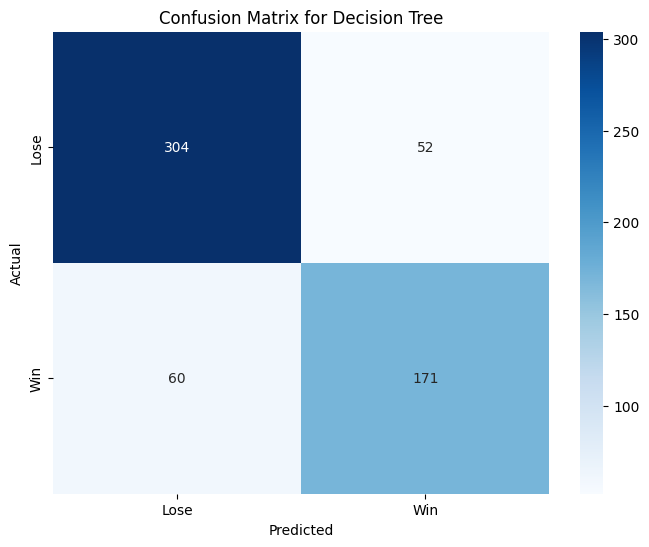

In [ ]:
# Decision Tree
print("Decision Tree:")
model_dt = Pipeline([('trf', trf), ('dt', DecisionTreeClassifier(random_state=42))])
model_dt.fit(X_train, y_train)
evaluate_model(model_dt, X_test, y_test)
print("-" * 30)

plot_confusion_matrix(model_dt, X_test, y_test, "Decision Tree")

Random Forest:
Accuracy: 0.8944
Precision: 0.8967
Recall: 0.8268
F1 Score: 0.8604
AUC-ROC: 0.9557
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       356
           1       0.90      0.83      0.86       231

    accuracy                           0.89       587
   macro avg       0.89      0.88      0.89       587
weighted avg       0.89      0.89      0.89       587

------------------------------


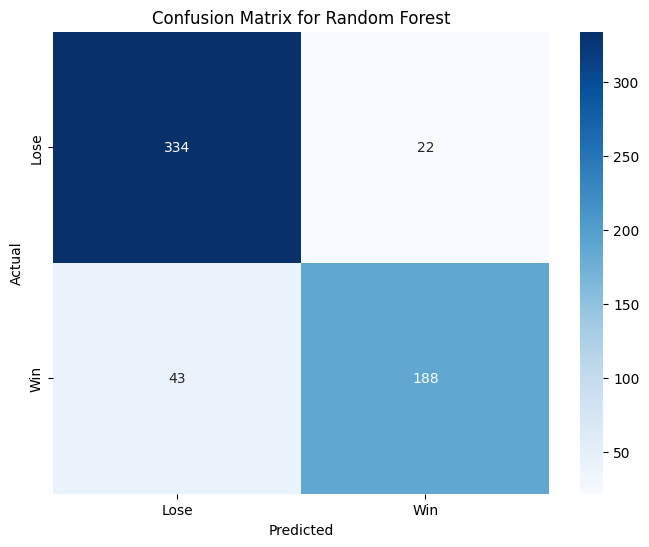

In [ ]:
# Random Forest
print("Random Forest:")
model_rf = Pipeline([('trf', trf), ('rf', RandomForestClassifier(random_state=42))])
model_rf.fit(X_train, y_train)
evaluate_model(model_rf, X_test, y_test)
print("-" * 30)

plot_confusion_matrix(model_rf, X_test, y_test, "Random Forest")

XGBoost:
Accuracy: 0.8842
Precision: 0.8655
Recall: 0.8355
F1 Score: 0.8502
AUC-ROC: 0.9540
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       356
           1       0.87      0.84      0.85       231

    accuracy                           0.88       587
   macro avg       0.88      0.88      0.88       587
weighted avg       0.88      0.88      0.88       587

------------------------------


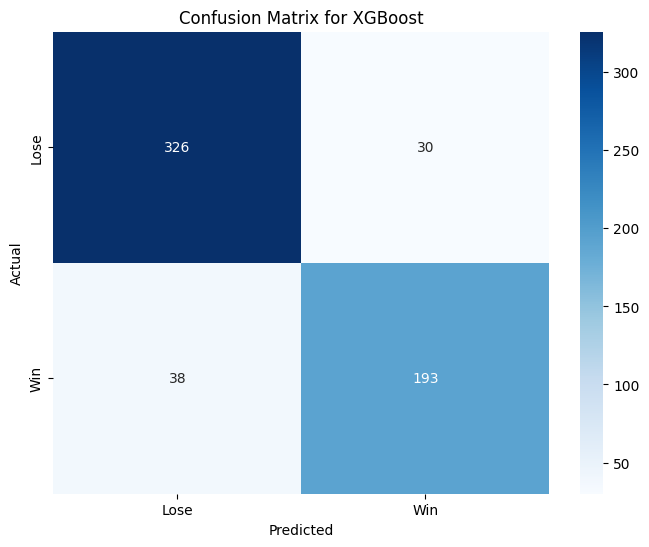

In [ ]:
# XGBoost
print("XGBoost:")
model_xgb = Pipeline([('trf', trf), ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))]) # use eval_metric
model_xgb.fit(X_train, y_train)
evaluate_model(model_xgb, X_test, y_test)
print("-" * 30)

plot_confusion_matrix(model_xgb, X_test, y_test, "XGBoost")

## ***Choosing Random Forest Predictor (Best Performing Model)***



In [36]:
best_model = model_rf

# Get user input
def get_user_input():
    bt = input("Batting team: ")
    bl = input("Bowling team: ")
    city = input("City: ")
    rl = int(input("Runs left: "))
    bls = int(input("Balls left: "))
    wk = int(input("Wickets left: "))
    tgt = int(input("Target score: "))

    # Calculate rates
    crr = ((tgt - rl + 1)*6)/(120 - bls) if bls < 120 else 0
    rrr = (rl*6)/bls if bls > 0 else float('inf')

    return pd.DataFrame([{
        'batting_team': bt,
        'bowling_team': bl,
        'city': city,
        'runs_left': rl,
        'balls_left': bls,
        'wickets': wk,
        'target': tgt,
        'crr': crr,
        'rrr': rrr
    }])


# Predict and print results
def predict_and_print(model, input_data):
    try:
      p = model.predict_proba(input_data)[0]
      print(f"\nWin probability : {p[1]*100:.1f}%")
      print(f"Lose probability: {p[0]*100:.1f}%\n")
    except ValueError as e:
      if "Found unknown categories" in str(e):
        print("Error: Unknown categories in the input data. Please check your input.")
      else:
        print(f"An error occurred: {e}")


# Main execution
user_input = get_user_input()
predict_and_print(best_model, user_input)


Batting team: Delhi Capitals
Bowling team: Chennai Superkings
City: Chennai
Runs left: 213
Balls left: 120
Wickets left: 10
Target score: 213

Win probability : 17.0%
Lose probability: 83.0%



In [38]:
def get_user_input():
    bt = input("Batting team: ")
    bl = input("Bowling team: ")
    city = input("City: ")
    return bt, bl, city

def predict_and_print(model, input_data):
    try:
      p = model.predict_proba(input_data)[0]
      print(f"\nWin probability : {p[1]*100:.1f}%")
      print(f"Lose probability: {p[0]*100:.1f}%\n")
    except ValueError as e:
      if "Found unknown categories" in str(e):
        print("Error: Unknown categories in the input data. Please check your input.")
      else:
        print(f"An error occurred: {e}")

# Assuming 'best_model' and necessary preprocessing steps (ohe, trf) are defined from previous code
# Example usage
user_input = get_user_input()
batting_team, bowling_team, city = user_input

# Create a DataFrame for the input
input_data = pd.DataFrame({
    'batting_team': [batting_team],
    'bowling_team': [bowling_team],
    'city': [city],
    'runs_left': [0],  # Placeholder values
    'balls_left': [0],  # Placeholder values
    'wickets': [10],  # Placeholder values
    'target': [0],  # Placeholder values
    'crr': [0],  # Placeholder values
    'rrr': [0]  # Placeholder values
})

predict_and_print(best_model, input_data)


Batting team: Chennai Superkings
Bowling team: Mumbai Indians
City: Chennai

Win probability : 75.0%
Lose probability: 25.0%

